# Flagship Oncology, Patient → Data → Dataset → Analysis → Tables/Figures → Decision

This notebook is a standalone oncology analytics proof of concept.

It does six things in one place:

1. **Patient**: define a realistic randomized phase II oncology cohort.
2. **Data**: simulate raw study data using literature-informed assumptions.
3. **Dataset**: build analysis-ready datasets.
4. **Analysis**: run survival, response, biomarker, tumor, exposure, and safety analyses.
5. **Tables/Figures**: save publication-style outputs.
6. **Decision**: produce an executive interpretation.

## Important note
This is a **synthetic dataset**. It is calibrated to broad patterns reported in published oncology studies and reviews, not copied from any patient-level trial data.

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf, sqrt, log, exp

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

BASE = Path("")
PROJ_DIR = BASE / "flagship_oncology_patient_to_decision"
RAW_DIR = PROJ_DIR / "raw"
ADAM_DIR = PROJ_DIR / "adam"
OUT_DIR = PROJ_DIR / "outputs"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
TXT_DIR = OUT_DIR / "listings"

for d in [RAW_DIR, ADAM_DIR, TAB_DIR, FIG_DIR, TXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)
STUDYID = "aAideaFLAG01"

def normal_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def approx_rate_hr(df):
    # incidence-rate HR approximation
    d = df.copy()
    eps = 1e-9
    out = {}
    for arm in ["Control","Treatment"]:
        sub = d[d["TRT01A"] == arm]
        events = float((1 - sub["CNSR"]).sum())
        ptime = float(sub["AVAL"].sum())
        out[arm] = {"events": events, "ptime": max(ptime, eps)}
    hr = (out["Treatment"]["events"] / out["Treatment"]["ptime"]) / (out["Control"]["events"] / out["Control"]["ptime"] + eps)
    se = sqrt(1/max(out["Treatment"]["events"],1) + 1/max(out["Control"]["events"],1))
    lcl = exp(log(max(hr, eps)) - 1.96*se)
    ucl = exp(log(max(hr, eps)) + 1.96*se)
    z = log(max(hr, eps)) / se if se > 0 else np.nan
    p = 2*(1 - normal_cdf(abs(z))) if np.isfinite(z) else np.nan
    return {"hr": hr, "lcl": lcl, "ucl": ucl, "p_value": p}

def km_curve(times, events):
    df = pd.DataFrame({"time": np.asarray(times, dtype=float), "event": np.asarray(events, dtype=int)})
    df = df.sort_values(["time","event"])
    event_times = np.sort(df.loc[df["event"] == 1, "time"].unique())
    surv = 1.0
    out = [{"time": 0.0, "surv": 1.0}]
    for t in event_times:
        n_at_risk = int((df["time"] >= t).sum())
        d_i = int(((df["time"] == t) & (df["event"] == 1)).sum())
        if n_at_risk > 0:
            surv *= (1 - d_i / n_at_risk)
        out.append({"time": float(t), "surv": float(surv)})
    return pd.DataFrame(out)

def km_median(km_df):
    hit = km_df[km_df["surv"] <= 0.5]
    return np.nan if hit.empty else float(hit["time"].iloc[0])

print("Project directory:", PROJ_DIR)

Project directory: flagship_oncology_patient_to_decision


## 1. Patient

We start with the patient.  
The simulated study is a randomized phase II oncology study with:
- 220 patients,
- 1:1 allocation,
- up to 24 months follow-up,
- endpoints: OS, PFS, BOR/ORR, grade 3+ AE,
- longitudinal tumor burden, labs, and ctDNA.

In [33]:
N = 220
patient_ids = [f"P{i:04d}" for i in range(1, N + 1)]
site_ids = [f"S{i:02d}" for i in range(1, 16)]

def trunc_norm(mean, sd, low, high, size):
    x = RNG.normal(mean, sd, size)
    return np.clip(x, low, high)

def zscore(s):
    s = pd.Series(s)
    return (s - s.mean()) / s.std(ddof=0)

study_start = pd.Timestamp("2022-01-01")
visits_spec = [
    ("Screening", 0, -14), ("Baseline", 1, 1), ("Week 3", 2, 22), ("Week 6", 3, 43),
    ("Week 12", 4, 85), ("Week 18", 5, 127), ("Week 24", 6, 169), ("Week 36", 7, 253),
    ("Week 48", 8, 337), ("Week 60", 9, 421), ("Week 72", 10, 505),
]

demog = pd.DataFrame({
    "patient_id": patient_ids,
    "site_id": RNG.choice(site_ids, size=N, replace=True),
    "country": RNG.choice(["UK","Germany","France","Spain","Italy"], p=[0.35,0.20,0.15,0.15,0.15], size=N),
    "treatment_arm": np.where(RNG.binomial(1, 0.5, N)==1, "Treatment", "Control"),
    "sex": RNG.choice(["Male","Female"], p=[0.55,0.45], size=N),
    "age": np.round(trunc_norm(62,10,28,85,N)).astype(int),
    "race": RNG.choice(["White","Asian","Black","Other"], p=[0.65,0.20,0.08,0.07], size=N),
    "ethnicity": RNG.choice(["Hispanic or Latino","Not Hispanic or Latino"], p=[0.12,0.88], size=N),
    "ecog": RNG.choice([0,1,2], p=[0.30,0.50,0.20], size=N),
    "smoking_status": RNG.choice(["Never","Former","Current"], p=[0.45,0.35,0.20], size=N),
    "biomarker_status": RNG.choice(["Positive","Negative"], p=[0.40,0.60], size=N),
})
demog["height_cm"] = np.where(demog["sex"].eq("Male"), trunc_norm(175,8,150,205,N), trunc_norm(162,7,140,190,N))
demog["weight_kg"] = np.where(demog["sex"].eq("Male"), trunc_norm(80,14,45,160,N), trunc_norm(68,13,40,150,N))
demog["bmi"] = demog["weight_kg"] / ((demog["height_cm"]/100.0)**2)
demog["baseline_ldh"] = np.clip(RNG.lognormal(np.log(230), 0.40, N), 100, 800)
demog["baseline_crp"] = np.clip(RNG.lognormal(np.log(10), 0.75, N), 0.5, 120)
demog["baseline_albumin"] = trunc_norm(3.9, 0.35, 2.2, 5.0, N)
demog["baseline_ctdna"] = np.clip(RNG.beta(1.7, 6.5, N) * 0.65, 0.001, 0.60)
demog["baseline_tumor_burden"] = trunc_norm(100, 30, 20, 220, N)
demog["screen_date"] = study_start + pd.to_timedelta(RNG.integers(0,366,N), unit="D")
demog["rand_date"] = demog["screen_date"] + pd.to_timedelta(RNG.integers(1,15,N), unit="D")
demog.head()

,patient_id,site_id,country,treatment_arm,sex,age,race,ethnicity,ecog,smoking_status,biomarker_status,height_cm,weight_kg,bmi,baseline_ldh,baseline_crp,baseline_albumin,baseline_ctdna,baseline_tumor_burden,screen_date,rand_date
0,P0001,S02,Germany,Treatment,Male,72,White,Not Hispanic or Latino,0,Never,Negative,178.983,91.871,28.678,256.931,9.181,3.801,0.161,90.552,2022-12-21,2022-12-22
1,P0002,S12,UK,Control,Male,74,Black,Not Hispanic or Latino,0,Current,Negative,175.818,99.288,32.120,134.010,37.907,4.006,0.215,172.800,2022-09-25,2022-10-07
2,P0003,S10,UK,Treatment,Male,52,White,Not Hispanic or Latino,2,Never,Negative,166.016,79.968,29.015,203.044,11.965,3.944,0.380,75.490,2022-01-30,2022-02-05
3,P0004,S07,France,Treatment,Female,43,White,Not Hispanic or Latino,0,Never,Positive,164.915,67.342,24.761,170.653,12.249,3.811,0.134,108.938,2022-05-30,2022-06-10
4,P0005,S07,UK,Control,Male,63,White,Not Hispanic or Latino,1,Current,Positive,165.202,70.175,25.713,325.691,5.057,3.362,0.205,77.493,2022-09-25,2022-09-27


## 2. Data

We now simulate raw trial data.

### Literature-informed design principles
- Worse ECOG, LDH, CRP, ctDNA, and tumor burden worsen outcomes.
- Better albumin improves outcomes.
- Treatment improves outcomes, especially in biomarker-positive patients.
- Responders show deeper tumor shrinkage and faster ctDNA decline.

In [36]:
trt = demog["treatment_arm"].eq("Treatment").astype(int)
bm = demog["biomarker_status"].eq("Positive").astype(int)
ecog2 = demog["ecog"].eq(2).astype(int)

risk = (
    0.18*zscore(demog["age"]) + 0.35*demog["ecog"] + 0.22*zscore(demog["baseline_tumor_burden"]) +
    0.25*zscore(demog["baseline_ldh"]) + 0.20*zscore(demog["baseline_crp"]) -
    0.22*zscore(demog["baseline_albumin"]) + 0.25*zscore(demog["baseline_ctdna"])
)

os_lp = risk - 0.30*trt - 0.18*trt*bm + 0.10*trt*ecog2
pfs_lp = risk - 0.35*trt - 0.22*trt*bm + 0.10*trt*ecog2

haz_os = (1/420) * np.exp(os_lp)
haz_pfs = (1/220) * np.exp(pfs_lp)

event_os = RNG.exponential(scale=1/haz_os)
event_pfs = RNG.exponential(scale=1/haz_pfs)
censor = RNG.integers(180, 731, N)

demog["os_days"] = np.minimum(event_os, censor).round().astype(int)
demog["os_event"] = (event_os <= censor).astype(int)
pfs_days = np.minimum(event_pfs, np.minimum(censor, demog["os_days"]))
demog["pfs_days"] = np.maximum(np.round(pfs_days).astype(int), 30)
demog["pfs_event"] = ((event_pfs <= censor) & (event_pfs <= demog["os_days"])).astype(int)

resp_logit = (
    -0.9 + 0.55*trt + 0.30*trt*bm - 0.20*demog["ecog"] - 0.18*zscore(demog["baseline_ldh"]) -
    0.15*zscore(demog["baseline_crp"]) + 0.18*zscore(demog["baseline_albumin"]) - 0.20*zscore(demog["baseline_ctdna"])
)
resp_prob = 1/(1+np.exp(-resp_logit))
responder = RNG.binomial(1, resp_prob, N)

bor = []
for r in responder:
    bor.append(RNG.choice(["CR","PR","SD","PD"], p=[0.08,0.62,0.20,0.10] if r==1 else [0.00,0.05,0.45,0.50]))
demog["BOR"] = bor
demog["responder_flag"] = demog["BOR"].isin(["CR","PR"]).astype(int)
demog["clinical_benefit_flag"] = demog["BOR"].isin(["CR","PR","SD"]).astype(int)

demog["death_date"] = pd.NaT
mask_os = demog["os_event"].eq(1)
demog.loc[mask_os, "death_date"] = demog.loc[mask_os, "rand_date"] + pd.to_timedelta(demog.loc[mask_os, "os_days"], unit="D")
demog["progression_date"] = pd.NaT
mask_pfs = demog["pfs_event"].eq(1)
demog.loc[mask_pfs, "progression_date"] = demog.loc[mask_pfs, "rand_date"] + pd.to_timedelta(demog.loc[mask_pfs, "pfs_days"], unit="D")

withdrawal_flag = RNG.binomial(1, 0.15, N)
wdt = demog["rand_date"] + pd.to_timedelta(RNG.integers(30,501,N), unit="D")
demog["withdrawal_date"] = pd.NaT
demog.loc[withdrawal_flag==1, "withdrawal_date"] = wdt[withdrawal_flag==1].values
demog["withdrawal_reason"] = np.where(withdrawal_flag==1, RNG.choice(["Adverse Event","Withdrew Consent","Lost to Follow-up","Physician Decision"], size=N), None)
demog["last_contact_date"] = demog["rand_date"] + pd.to_timedelta(RNG.integers(180,731,N), unit="D")
demog["last_contact_date"] = demog[["last_contact_date","withdrawal_date"]].min(axis=1)
demog["last_contact_date"] = demog[["last_contact_date","death_date"]].max(axis=1)

demog[["patient_id","treatment_arm","biomarker_status","BOR","os_days","os_event","pfs_days","pfs_event"]].head(10)

,patient_id,treatment_arm,biomarker_status,BOR,os_days,os_event,pfs_days,pfs_event
0,P0001,Treatment,Negative,PD,366,1,366,0
1,P0002,Control,Negative,PD,130,1,130,0
2,P0003,Treatment,Negative,PD,23,1,30,0
3,P0004,Treatment,Positive,SD,448,1,448,0
4,P0005,Control,Positive,SD,8,1,30,0
5,P0006,Treatment,Negative,SD,2,1,30,0
6,P0007,Control,Negative,SD,374,1,32,1
7,P0008,Treatment,Negative,PR,78,1,78,0
8,P0009,Control,Negative,PD,631,0,136,1
9,P0010,Treatment,Negative,SD,181,1,30,1


In [38]:
visit_rows = []
for _, r in demog.iterrows():
    end_date = r["death_date"] if pd.notna(r["death_date"]) else r["last_contact_date"]
    for visit_name, visit_num, plan_day in visits_spec:
        actual_day = int(round(plan_day + RNG.normal(0, 3)))
        visit_date = r["rand_date"] + pd.to_timedelta(actual_day, unit="D")
        if visit_date <= end_date:
            cycle = max(1, int(np.floor(max(actual_day,1)/21)) + 1)
            visit_rows.append({
                "patient_id": r["patient_id"], "visit_name": visit_name, "visit_num": visit_num,
                "visit_date": visit_date, "study_day": actual_day, "cycle": cycle,
                "planned_flag": "Y", "visit_window_deviation_days": actual_day - plan_day
            })
visits = pd.DataFrame(visit_rows).sort_values(["patient_id","visit_num"]).reset_index(drop=True)
visits.head()

,patient_id,visit_name,visit_num,visit_date,study_day,cycle,planned_flag,visit_window_deviation_days
0,P0001,Screening,0,2022-12-08,-14,1,Y,0
1,P0001,Baseline,1,2022-12-29,7,1,Y,6
2,P0001,Week 3,2,2023-01-13,22,2,Y,0
3,P0001,Week 6,3,2023-02-03,43,3,Y,0
4,P0001,Week 12,4,2023-03-19,87,5,Y,2


In [40]:
demog["grade3_risk"] = 1/(1+np.exp(-(-1.8 + 0.30*trt + 0.18*demog["ecog"] + 0.10*zscore(demog["baseline_ldh"]))))
demog["any_ae_risk"] = 1/(1+np.exp(-(-0.2 + 0.3*trt + 0.15*demog["ecog"] + 0.10*zscore(demog["age"]))))

dose_levels = [50,100,150,200]
dose_probs = [0.20,0.35,0.30,0.15]
demog["assigned_dose_mg"] = np.where(demog["treatment_arm"].eq("Treatment"), RNG.choice(dose_levels, p=dose_probs, size=N), 0)

exp_rows = []
for _, r in demog.iterrows():
    pv = visits[(visits["patient_id"] == r["patient_id"]) & (visits["study_day"] >= 1)]
    current_dose = int(r["assigned_dose_mg"])
    for _, v in pv.iterrows():
        if r["treatment_arm"] == "Control":
            exp_rows.append({
                "patient_id": r["patient_id"], "dose_date": v["visit_date"], "cycle": v["cycle"], "day_in_cycle": ((max(v["study_day"],1)-1)%21)+1,
                "dose_mg": 0, "dose_unit": "mg", "dose_form": "NA", "dose_administered_flag": "N",
                "dose_reduction_flag": "N", "dose_interruption_flag": "N", "dose_reason": "Control"
            })
        else:
            red = int(RNG.random() < min(0.05 + 0.30*r["grade3_risk"], 0.55))
            intr = int(RNG.random() < min(0.04 + 0.22*r["grade3_risk"], 0.45))
            if red and current_dose > 50:
                current_dose = max(50, current_dose - 50)
            admin = 0 if intr else 1
            reason = "Dose as planned"
            if intr:
                reason = "Toxicity interruption"
            elif red:
                reason = "Dose reduction due to toxicity"
            exp_rows.append({
                "patient_id": r["patient_id"], "dose_date": v["visit_date"], "cycle": v["cycle"], "day_in_cycle": ((max(v["study_day"],1)-1)%21)+1,
                "dose_mg": current_dose if admin else 0, "dose_unit": "mg", "dose_form": "Tablet", "dose_administered_flag": "Y" if admin else "N",
                "dose_reduction_flag": "Y" if red else "N", "dose_interruption_flag": "Y" if intr else "N", "dose_reason": reason
            })
exposure_raw = pd.DataFrame(exp_rows)
exposure_raw.head()

,patient_id,dose_date,cycle,day_in_cycle,dose_mg,dose_unit,dose_form,dose_administered_flag,dose_reduction_flag,dose_interruption_flag,dose_reason
0,P0001,2022-12-29,1,7,100,mg,Tablet,Y,N,N,Dose as planned
1,P0001,2023-01-13,2,1,0,mg,Tablet,N,N,Y,Toxicity interruption
2,P0001,2023-02-03,3,1,100,mg,Tablet,Y,N,N,Dose as planned
3,P0001,2023-03-19,5,3,100,mg,Tablet,Y,N,N,Dose as planned
4,P0001,2023-04-20,6,14,50,mg,Tablet,Y,Y,N,Dose reduction due to toxicity


In [42]:
lab_meta = {
    "ALT": ("U/L", 7, 56), "AST": ("U/L", 10, 40), "Creatinine": ("mg/dL", 0.6, 1.3),
    "Hemoglobin": ("g/dL", 11.5, 17.5), "Neutrophils": ("10^9/L", 1.8, 7.5),
    "Platelets": ("10^9/L", 150, 450), "LDH": ("U/L", 120, 250), "CRP": ("mg/L", 0, 10), "Albumin": ("g/dL", 3.4, 5.0)
}
tumor_rows, bio_rows, lab_rows = [], [], []
for _, r in demog.iterrows():
    pv = visits[visits["patient_id"] == r["patient_id"]].sort_values("study_day")
    base = float(r["baseline_tumor_burden"])
    if r["treatment_arm"] == "Treatment" and r["responder_flag"] == 1:
        slope = RNG.normal(-0.10, 0.04)
    elif r["treatment_arm"] == "Treatment":
        slope = RNG.normal(-0.01, 0.05)
    else:
        slope = RNG.normal(0.04, 0.05)

    alt_base = max(5, RNG.normal(28,8)); ast_base = max(5, RNG.normal(24,7)); creat_base = max(0.4, RNG.normal(0.95,0.18))
    hgb_base = max(7, RNG.normal(12.5,1.4)); neut_base = max(0.2, RNG.normal(4.2,1.2)); plt_base = max(30, RNG.normal(260,70))
    il6_base = max(0.5, RNG.normal(12,5)); tnfa_base = max(0.5, RNG.normal(10,4))
    ifng_base = max(0.5, RNG.normal(8 + 4*(r["biomarker_status"]=="Positive"), 3))
    vegf_base = max(1, RNG.normal(200 + 0.8*base, 60))
    ki67_base = np.clip(RNG.normal(35 + 0.08*base, 10), 5, 95)
    pdl1_base = np.clip(RNG.normal(20 + 15*(r["biomarker_status"]=="Positive"), 12), 0, 100)
    progressor = int(r["BOR"] == "PD")

    for _, v in pv.iterrows():
        t_months = max(v["study_day"],1) / 30.4
        tumor = max(2, base * (1 + slope*t_months) + RNG.normal(0,5))
        pct = 100*(tumor - base)/base
        inv = "CR" if pct <= -99 else ("PR" if pct <= -30 else ("PD" if pct >= 20 else "SD"))
        new_les = "Y" if ((r["BOR"]=="PD") and (v["study_day"] >= r["pfs_days"]) and RNG.random() < 0.35) else "N"
        non_target = "Y" if ((r["BOR"]=="PD") and (v["study_day"] >= r["pfs_days"]) and RNG.random() < 0.40) else "N"
        tumor_rows.append({
            "patient_id": r["patient_id"], "visit_name": v["visit_name"], "visit_date": v["visit_date"], "study_day": v["study_day"],
            "lesion_group": "TARGET", "sum_target_lesions_mm": tumor, "new_lesion_flag": new_les,
            "non_target_progression_flag": non_target, "bor_assessment": r["BOR"], "investigator_response": inv
        })

        if r["treatment_arm"] == "Treatment" and r["responder_flag"] == 1:
            ctdna = r["baseline_ctdna"] * max(0.05, 1 - 0.20*t_months) + RNG.normal(0,0.01)
        elif r["treatment_arm"] == "Treatment":
            ctdna = r["baseline_ctdna"] * max(0.15, 1 - 0.05*t_months) + RNG.normal(0,0.015)
        else:
            ctdna = r["baseline_ctdna"] * (1 + 0.04*t_months) + RNG.normal(0,0.015)
        ctdna = float(np.clip(ctdna, 0.0001, 0.80))
        il6 = max(0.1, il6_base + 1.0*t_months*progressor + RNG.normal(0,1.8))
        tnfa = max(0.1, tnfa_base + 0.6*t_months*progressor + RNG.normal(0,1.3))
        ifng = max(0.1, ifng_base + 1.2*t_months*(r["treatment_arm"]=="Treatment")*(r["biomarker_status"]=="Positive") + RNG.normal(0,1.5))
        vegf = max(1, vegf_base * (0.9 + 0.1*(tumor/base)) + RNG.normal(0,15))
        ki67 = float(np.clip(ki67_base * (0.92 + 0.08*(tumor/base)) + RNG.normal(0,2), 0, 100))
        pdl1 = float(np.clip(pdl1_base + RNG.normal(0,4), 0, 100))
        for name, val, unit in [
            ("ctDNA_fraction", ctdna, "fraction"), ("IL6", il6, "pg/mL"), ("TNFa", tnfa, "pg/mL"),
            ("IFNg", ifng, "pg/mL"), ("VEGF", vegf, "pg/mL"), ("Ki67_score", ki67, "%"), ("PDL1_score", pdl1, "%")
        ]:
            bio_rows.append({"patient_id": r["patient_id"], "visit_name": v["visit_name"], "visit_date": v["visit_date"], "study_day": v["study_day"], "biomarker_name": name, "biomarker_value": val, "biomarker_unit": unit})

        vals = {
            "ALT": np.clip(alt_base + RNG.normal(0,6) + 8*r["grade3_risk"], 5, 500),
            "AST": np.clip(ast_base + RNG.normal(0,6) + 7*r["grade3_risk"], 5, 500),
            "Creatinine": np.clip(creat_base + RNG.normal(0,0.08) + 0.06*r["grade3_risk"], 0.3, 4),
            "Hemoglobin": np.clip(hgb_base - 0.08*t_months - 0.15*progressor*t_months + RNG.normal(0,0.4), 6, 18),
            "Neutrophils": np.clip(neut_base - 0.15*(r["treatment_arm"]=="Treatment")*t_months + RNG.normal(0,0.35), 0.1, 15),
            "Platelets": np.clip(plt_base - 2.5*(r["treatment_arm"]=="Treatment")*t_months + RNG.normal(0,14), 20, 900),
            "LDH": np.clip(r["baseline_ldh"]*(0.80 + 0.20*(tumor/base)) + RNG.normal(0,12), 50, 2000),
            "CRP": np.clip(r["baseline_crp"]*(0.75 + 0.25*(tumor/base)) + RNG.normal(0,1.5), 0.1, 250),
            "Albumin": np.clip(r["baseline_albumin"] - 0.08*t_months*progressor + RNG.normal(0,0.08), 1.5, 5.5),
        }
        for lab, val in vals.items():
            unit, low, high = lab_meta[lab]
            lab_rows.append({"patient_id": r["patient_id"], "visit_name": v["visit_name"], "visit_date": v["visit_date"], "study_day": v["study_day"], "lab_test": lab, "lab_value": val, "lab_unit": unit, "lab_low": low, "lab_high": high, "lab_abnormal_flag": "L" if val < low else ("H" if val > high else "N"), "lab_clin_sig_flag": "Y" if (val < low*0.7 or val > high*1.5) else "N"})

tumor_raw = pd.DataFrame(tumor_rows)
biomarker_raw = pd.DataFrame(bio_rows)
labs_raw = pd.DataFrame(lab_rows)
tumor_raw.head()

,patient_id,visit_name,visit_date,study_day,lesion_group,sum_target_lesions_mm,new_lesion_flag,non_target_progression_flag,bor_assessment,investigator_response
0,P0001,Screening,2022-12-08,-14,TARGET,85.770,N,N,PD,SD
1,P0001,Baseline,2022-12-29,7,TARGET,91.945,N,N,PD,SD
2,P0001,Week 3,2023-01-13,22,TARGET,84.806,N,N,PD,SD
3,P0001,Week 6,2023-02-03,43,TARGET,96.528,N,N,PD,SD
4,P0001,Week 12,2023-03-19,87,TARGET,98.153,N,N,PD,SD


In [44]:
ae_terms = [
    ("Nausea", "Gastrointestinal disorders"), ("Fatigue", "General disorders"), ("Anemia", "Blood and lymphatic system disorders"),
    ("Neutropenia", "Blood and lymphatic system disorders"), ("Diarrhea", "Gastrointestinal disorders"),
    ("Rash", "Skin and subcutaneous tissue disorders"), ("ALT increased", "Investigations"),
    ("AST increased", "Investigations"), ("Infection", "Infections and infestations"),
    ("Decreased appetite", "Metabolism and nutrition disorders"),
]
ae_rows = []
for _, r in demog.iterrows():
    for _ in range(RNG.poisson(2.1 + 0.8*r["any_ae_risk"])):
        term, soc = ae_terms[RNG.integers(0, len(ae_terms))]
        if r["treatment_arm"] == "Treatment" and RNG.random() < 0.35:
            term, soc = ae_terms[RNG.integers(4, 9)]
        start_day = int(RNG.integers(1, 181))
        start_date = r["rand_date"] + pd.to_timedelta(start_day, unit="D")
        end_date = start_date + pd.to_timedelta(int(RNG.integers(3, 31)), unit="D")
        grade = int(RNG.choice([1,2,3,4], p=[0.45,0.30,0.20,0.05]))
        serious = "Y" if (grade >= 3 and RNG.random() < 0.42) else "N"
        related = "Y" if RNG.random() < (0.60 if r["treatment_arm"]=="Treatment" else 0.30) else "N"
        if grade <= 2:
            action = RNG.choice(["None","Symptomatic treatment"], p=[0.75,0.25])
        elif grade == 3:
            action = RNG.choice(["Dose reduced","Drug interrupted","Hospitalized"], p=[0.35,0.45,0.20])
        else:
            action = RNG.choice(["Drug interrupted","Withdrawn","Hospitalized"], p=[0.35,0.35,0.30])
        outcome = RNG.choice(["Recovered","Recovering","Not recovered"], p=[0.60,0.25,0.15])
        aesi = "Y" if term in ["ALT increased","AST increased","Neutropenia","Infection"] and grade >= 3 else "N"
        death_ae = "Y" if (grade == 4 and serious == "Y" and RNG.random() < 0.03) else "N"
        ae_rows.append({"patient_id": r["patient_id"], "ae_term": term, "ae_soc": soc, "ae_start_date": start_date, "ae_end_date": end_date, "ae_grade": grade, "serious_flag": serious, "related_flag": related, "action_taken": action, "outcome": outcome, "aesI_flag": aesi, "death_ae_flag": death_ae})
adverse_events_raw = pd.DataFrame(ae_rows)
adverse_events_raw.head()

,patient_id,ae_term,ae_soc,ae_start_date,ae_end_date,ae_grade,serious_flag,related_flag,action_taken,outcome,aesI_flag,death_ae_flag
0,P0001,Anemia,Blood and lymphatic system disorders,2023-01-19,2023-02-17,1,N,Y,None,Recovered,N,N
1,P0001,Infection,Infections and infestations,2023-03-26,2023-04-13,3,N,Y,Dose reduced,Recovered,Y,N
2,P0002,Infection,Infections and infestations,2023-02-25,2023-03-10,2,N,Y,None,Recovered,N,N
3,P0002,Decreased appetite,Metabolism and nutrition disorders,2023-03-31,2023-04-21,3,N,Y,Dose reduced,Recovered,N,N
4,P0002,Decreased appetite,Metabolism and nutrition disorders,2023-03-21,2023-03-25,2,N,Y,Symptomatic treatment,Recovering,N,N


In [46]:
cm_classes = {
    "Paracetamol": ("Analgesics", "Pain"), "Ondansetron": ("Antiemetics", "Nausea"),
    "Amoxicillin": ("Antibiotics", "Infection"), "Dexamethasone": ("Corticosteroids", "Inflammation"),
    "Omeprazole": ("Proton pump inhibitors", "Gastric protection"),
}
cm_rows = []
for _, r in demog.iterrows():
    for _ in range(RNG.poisson(1.5)):
        term = RNG.choice(list(cm_classes))
        cls, ind = cm_classes[term]
        start_day = int(RNG.integers(-7,121))
        dur = int(RNG.integers(7,121))
        cm_rows.append({"patient_id": r["patient_id"], "cm_term": term, "cm_class": cls, "cm_start_date": r["rand_date"] + pd.to_timedelta(start_day, unit="D"), "cm_end_date": r["rand_date"] + pd.to_timedelta(start_day + dur, unit="D"), "indication": ind})
conmeds_raw = pd.DataFrame(cm_rows)

survival_raw = demog[["patient_id","progression_date","death_date","last_contact_date","pfs_event","os_event"]].rename(columns={"last_contact_date":"last_alive_date","pfs_event":"pfs_event_flag","os_event":"os_event_flag"})
demographics_raw = demog[["patient_id","site_id","country","screen_date","rand_date","treatment_arm","sex","age","race","ethnicity","height_cm","weight_kg","bmi","ecog","smoking_status","biomarker_status","baseline_ldh","baseline_crp","baseline_albumin","baseline_ctdna","baseline_tumor_burden","death_date","last_contact_date","withdrawal_date","withdrawal_reason"]].copy()

for name, df in {
    "demographics_raw.csv": demographics_raw, "visits_raw.csv": visits, "exposure_raw.csv": exposure_raw,
    "labs_raw.csv": labs_raw, "tumor_raw.csv": tumor_raw, "biomarker_raw.csv": biomarker_raw,
    "adverse_events_raw.csv": adverse_events_raw, "conmeds_raw.csv": conmeds_raw, "survival_raw.csv": survival_raw,
}.items():
    df.to_csv(RAW_DIR / name, index=False)

print("Raw files written:", len(list(RAW_DIR.glob("*.csv"))))

Raw files written: 9


## 3. Dataset

Now we derive analysis-ready datasets.

In [49]:
dose_summary = exposure_raw.groupby("patient_id").agg(
    cumulative_dose=("dose_mg","sum"),
    n_doses=("dose_administered_flag", lambda s: int((pd.Series(s)=="Y").sum())),
    dose_reductions=("dose_reduction_flag", lambda s: int((pd.Series(s)=="Y").sum())),
    dose_interruptions=("dose_interruption_flag", lambda s: int((pd.Series(s)=="Y").sum())),
).reset_index()
planned_visits = visits[visits["study_day"] >= 1].groupby("patient_id").size().rename("planned_visits").reset_index()
dose_summary = dose_summary.merge(planned_visits, on="patient_id", how="left")
dose_summary["assigned_dose"] = dose_summary["patient_id"].map(demog.set_index("patient_id")["assigned_dose_mg"])
dose_summary["planned_cumulative_dose"] = dose_summary["assigned_dose"] * dose_summary["planned_visits"]
dose_summary["dose_intensity"] = np.where(dose_summary["planned_cumulative_dose"] > 0, dose_summary["cumulative_dose"] / dose_summary["planned_cumulative_dose"], np.nan)

pk = demog[["patient_id","assigned_dose_mg"]].copy()
pk["AUC_0_24"] = pk["assigned_dose_mg"] * RNG.uniform(18,30,len(pk)) * RNG.lognormal(0,0.20,len(pk))
pk["AUC_0_72"] = pk["assigned_dose_mg"] * RNG.uniform(45,85,len(pk)) * RNG.lognormal(0,0.20,len(pk))
pk["CMAX"] = pk["assigned_dose_mg"] * RNG.uniform(4,9,len(pk)) * RNG.lognormal(0,0.20,len(pk))

ae_flags = adverse_events_raw.groupby("patient_id").agg(
    GR3AEFL=("ae_grade", lambda s: "Y" if (pd.Series(s) >= 3).any() else "N"),
    SAEFL=("serious_flag", lambda s: "Y" if (pd.Series(s) == "Y").any() else "N"),
    DISCFL=("action_taken", lambda s: "Y" if pd.Series(s).isin(["Withdrawn"]).any() else "N"),
).reset_index()

adsl = demographics_raw.merge(dose_summary, on="patient_id", how="left").merge(pk, on="patient_id", how="left").merge(ae_flags, on="patient_id", how="left")
adsl["STUDYID"] = STUDYID
adsl["USUBJID"] = adsl["patient_id"]
adsl["SITEID"] = adsl["site_id"]
adsl["TRT01A"] = adsl["treatment_arm"]
adsl["TRT01P"] = adsl["treatment_arm"]
adsl["SAFFL"] = np.where(adsl["n_doses"].fillna(0) > 0, "Y", "N")
adsl["EFFFL"] = "Y"
adsl["ITTFL"] = "Y"
adsl["WEIGHTBL"] = adsl["weight_kg"]
adsl["BMIBL"] = adsl["bmi"]
adsl["LDHBL"] = adsl["baseline_ldh"]
adsl["CRPBL"] = adsl["baseline_crp"]
adsl["ALBBL"] = adsl["baseline_albumin"]
adsl["CTDNABL"] = adsl["baseline_ctdna"]
adsl["TUMORBL"] = adsl["baseline_tumor_burden"]
adsl["RANDDT"] = pd.to_datetime(adsl["rand_date"])
adsl["TRTSDT"] = adsl["RANDDT"]
adsl["TRTEDT"] = pd.to_datetime(adsl["last_contact_date"])
adsl["DTHDT"] = pd.to_datetime(adsl["death_date"])
adsl["LSTALVDT"] = pd.to_datetime(adsl["last_contact_date"])
adsl["EOSDT"] = pd.to_datetime(adsl["withdrawal_date"]).fillna(adsl["LSTALVDT"])
adsl["OSDAYS"] = demog["os_days"].values
adsl["CNSR_OS"] = np.where(demog["os_event"].values == 1, 0, 1)
adsl["PFDAYS"] = demog["pfs_days"].values
adsl["CNSR_PFS"] = np.where(demog["pfs_event"].values == 1, 0, 1)
adsl["BOR"] = demog["BOR"].values
adsl["RESPFL"] = np.where(adsl["BOR"].isin(["CR","PR"]), "Y", "N")
adsl["CBENFL"] = np.where(adsl["BOR"].isin(["CR","PR","SD"]), "Y", "N")
adsl["DOSEINTENSITY"] = adsl["dose_intensity"]
adsl["TRGHIGHFL"] = np.where(adsl["CTDNABL"] >= adsl["CTDNABL"].median(), "Y", "N")
for c in ["GR3AEFL","SAEFL","DISCFL"]:
    adsl[c] = adsl[c].fillna("N")

adsl = adsl[["STUDYID","USUBJID","SITEID","TRT01A","TRT01P","SAFFL","EFFFL","ITTFL","age","sex","race","country","ecog","WEIGHTBL","BMIBL","biomarker_status","LDHBL","CRPBL","ALBBL","CTDNABL","TUMORBL","RANDDT","TRTSDT","TRTEDT","DTHDT","LSTALVDT","EOSDT","OSDAYS","CNSR_OS","PFDAYS","CNSR_PFS","BOR","RESPFL","CBENFL","DOSEINTENSITY","AUC_0_24","AUC_0_72","CMAX","TRGHIGHFL","GR3AEFL","SAEFL","DISCFL"]].rename(columns={"age":"AGE","sex":"SEX","race":"RACE","country":"COUNTRY","ecog":"ECOG","biomarker_status":"BIOMARKER_STATUS"})

# ADTTE
adtte_rows = []
for _, r in adsl.iterrows():
    os_adt = r["DTHDT"] if pd.notna(r["DTHDT"]) else r["LSTALVDT"]
    adtte_rows.append({"STUDYID":r["STUDYID"],"USUBJID":r["USUBJID"],"PARAMCD":"OS","PARAM":"Overall survival","STARTDT":r["RANDDT"],"ADT":os_adt,"AVAL":r["OSDAYS"],"CNSR":r["CNSR_OS"],"EVNTDESC":"Death" if r["CNSR_OS"]==0 else "Censored","TRT01A":r["TRT01A"],"ECOG":r["ECOG"],"BIOMARKER_STATUS":r["BIOMARKER_STATUS"],"LDHBL":r["LDHBL"],"CTDNABL":r["CTDNABL"]})
    prog_dt = survival_raw.loc[survival_raw["patient_id"]==r["USUBJID"],"progression_date"]
    prog_dt = prog_dt.iloc[0] if len(prog_dt) else pd.NaT
    pfs_adt = prog_dt if pd.notna(prog_dt) else (r["DTHDT"] if pd.notna(r["DTHDT"]) else r["LSTALVDT"])
    adtte_rows.append({"STUDYID":r["STUDYID"],"USUBJID":r["USUBJID"],"PARAMCD":"PFS","PARAM":"Progression-free survival","STARTDT":r["RANDDT"],"ADT":pfs_adt,"AVAL":r["PFDAYS"],"CNSR":r["CNSR_PFS"],"EVNTDESC":"Progression/death" if r["CNSR_PFS"]==0 else "Censored","TRT01A":r["TRT01A"],"ECOG":r["ECOG"],"BIOMARKER_STATUS":r["BIOMARKER_STATUS"],"LDHBL":r["LDHBL"],"CTDNABL":r["CTDNABL"]})
adtte = pd.DataFrame(adtte_rows)

# ADTU
adtu = tumor_raw.merge(adsl[["USUBJID","TRT01A"]], left_on="patient_id", right_on="USUBJID", how="left")
base_tumor = tumor_raw[tumor_raw["visit_name"]=="Baseline"][["patient_id","sum_target_lesions_mm"]].rename(columns={"sum_target_lesions_mm":"BASE"})
adtu = adtu.merge(base_tumor, on="patient_id", how="left")
adtu["ADT"] = pd.to_datetime(adtu["visit_date"]); adtu["AVISIT"] = adtu["visit_name"]; adtu["AVISITN"] = adtu["study_day"]
adtu["AVAL"] = adtu["sum_target_lesions_mm"]; adtu["CHG"] = adtu["AVAL"] - adtu["BASE"]; adtu["PCHG"] = np.where(adtu["BASE"]!=0, 100*adtu["CHG"]/adtu["BASE"], np.nan)
adtu["BOR"] = adtu["bor_assessment"]; adtu["NEWLESFL"] = adtu["new_lesion_flag"]; adtu["PD_FL"] = np.where((adtu["investigator_response"]=="PD") | (adtu["NEWLESFL"]=="Y") | (adtu["non_target_progression_flag"]=="Y"), "Y", "N")
adtu["STUDYID"] = STUDYID
adtu = adtu[["STUDYID","USUBJID","ADT","AVISIT","AVISITN","AVAL","BASE","CHG","PCHG","BOR","NEWLESFL","PD_FL","TRT01A"]]

# ADBM
adbm = biomarker_raw.merge(adsl[["USUBJID","TRT01A","BIOMARKER_STATUS"]], left_on="patient_id", right_on="USUBJID", how="left")
base_bm = biomarker_raw[biomarker_raw["visit_name"]=="Baseline"][["patient_id","biomarker_name","biomarker_value"]].rename(columns={"biomarker_value":"BASE"})
adbm = adbm.merge(base_bm, on=["patient_id","biomarker_name"], how="left")
adbm["PARAMCD"] = adbm["biomarker_name"].str.upper().str.replace("_","", regex=False).str.slice(0,8)
adbm["PARAM"] = adbm["biomarker_name"]; adbm["ADT"] = pd.to_datetime(adbm["visit_date"]); adbm["AVISIT"] = adbm["visit_name"]; adbm["AVISITN"] = adbm["study_day"]; adbm["AVAL"] = adbm["biomarker_value"]; adbm["CHG"] = adbm["AVAL"] - adbm["BASE"]; adbm["PCHG"] = np.where(adbm["BASE"]!=0, 100*adbm["CHG"]/adbm["BASE"], np.nan); adbm["STUDYID"] = STUDYID
adbm = adbm[["STUDYID","USUBJID","PARAMCD","PARAM","ADT","AVISIT","AVISITN","AVAL","BASE","CHG","PCHG","TRT01A","BIOMARKER_STATUS"]]

# ADAE
adae = adverse_events_raw.merge(adsl[["USUBJID","TRT01A","TRTSDT"]], left_on="patient_id", right_on="USUBJID", how="left")
adae["AETOXGR"] = adae["ae_grade"]; adae["SERFL"] = np.where(adae["serious_flag"]=="Y","Y","N"); adae["RELFL"] = np.where(adae["related_flag"]=="Y","Y","N")
adae["ASTDT"] = pd.to_datetime(adae["ae_start_date"]); adae["AENDT"] = pd.to_datetime(adae["ae_end_date"]); adae["TRTEMFL"] = np.where(adae["ASTDT"] >= pd.to_datetime(adae["TRTSDT"]), "Y","N")
adae["ASTDY"] = (adae["ASTDT"] - pd.to_datetime(adae["TRTSDT"])).dt.days + 1; adae["AENDY"] = (adae["AENDT"] - pd.to_datetime(adae["TRTSDT"])).dt.days + 1
adae = adae.sort_values(["USUBJID","ae_term","ASTDT"]); adae["AOCCFL"] = np.where(adae.groupby(["USUBJID","ae_term"]).cumcount()==0,"Y","N"); adae["AESEQ"] = adae.groupby("USUBJID").cumcount() + 1; adae["STUDYID"] = STUDYID
adae = adae.rename(columns={"ae_term":"AETERM","ae_soc":"AESOC"})[["STUDYID","USUBJID","AESEQ","AETERM","AESOC","AETOXGR","SERFL","RELFL","TRTEMFL","AOCCFL","TRT01A","ASTDT","AENDT","ASTDY","AENDY"]]

# ADLB
adlb = labs_raw.merge(adsl[["USUBJID","TRT01A"]], left_on="patient_id", right_on="USUBJID", how="left")
base_lab = labs_raw[labs_raw["visit_name"]=="Baseline"][["patient_id","lab_test","lab_value"]].rename(columns={"lab_value":"BASE"})
adlb = adlb.merge(base_lab, on=["patient_id","lab_test"], how="left")
adlb["PARAMCD"] = adlb["lab_test"].str.upper().str.replace(" ","", regex=False).str.slice(0,8)
adlb["PARAM"] = adlb["lab_test"]; adlb["ADT"] = pd.to_datetime(adlb["visit_date"]); adlb["AVISIT"] = adlb["visit_name"]; adlb["AVISITN"] = adlb["study_day"]; adlb["AVAL"] = adlb["lab_value"]; adlb["CHG"] = adlb["AVAL"] - adlb["BASE"]; adlb["PCHG"] = np.where(adlb["BASE"]!=0, 100*adlb["CHG"]/adlb["BASE"], np.nan); adlb["ANRIND"] = adlb["lab_abnormal_flag"]; adlb["STUDYID"] = STUDYID
adlb = adlb[["STUDYID","USUBJID","PARAMCD","PARAM","ADT","AVISIT","AVISITN","AVAL","BASE","CHG","PCHG","ANRIND","TRT01A"]]

for name, df in {"ADSL.csv":adsl,"ADTTE.csv":adtte,"ADTU.csv":adtu,"ADBM.csv":adbm,"ADAE.csv":adae,"ADLB.csv":adlb}.items():
    df.to_csv(ADAM_DIR / name, index=False)

adsl.head()

,STUDYID,USUBJID,SITEID,TRT01A,TRT01P,SAFFL,EFFFL,ITTFL,AGE,SEX,RACE,COUNTRY,ECOG,WEIGHTBL,BMIBL,BIOMARKER_STATUS,LDHBL,CRPBL,ALBBL,CTDNABL,TUMORBL,RANDDT,TRTSDT,TRTEDT,DTHDT,LSTALVDT,EOSDT,OSDAYS,CNSR_OS,PFDAYS,CNSR_PFS,BOR,RESPFL,CBENFL,DOSEINTENSITY,AUC_0_24,AUC_0_72,CMAX,TRGHIGHFL,GR3AEFL,SAEFL,DISCFL
0,aAideaFLAG01,P0001,S02,Treatment,Treatment,Y,Y,Y,72,Male,White,Germany,0,91.871,28.678,Negative,256.931,9.181,3.801,0.161,90.552,2022-12-22,2022-12-22,2024-06-29,2023-12-23,2024-06-29,2024-06-29,366,0,366,1,PD,N,N,0.625,"3,177.586","6,326.891",464.637,Y,Y,N,N
1,aAideaFLAG01,P0002,S12,Control,Control,N,Y,Y,74,Male,Black,UK,0,99.288,32.120,Negative,134.010,37.907,4.006,0.215,172.800,2022-10-07,2022-10-07,2023-04-23,2023-02-14,2023-04-23,2023-04-23,130,0,130,1,PD,N,N,NaN,0.000,0.000,0.000,Y,Y,N,N
2,aAideaFLAG01,P0003,S10,Treatment,Treatment,Y,Y,Y,52,Male,White,UK,2,79.968,29.015,Negative,203.044,11.965,3.944,0.380,75.490,2022-02-05,2022-02-05,2022-07-23,2022-02-28,2022-07-23,2022-07-23,23,0,30,1,PD,N,N,0.750,"1,802.663","5,422.737",613.903,Y,N,N,N
3,aAideaFLAG01,P0004,S07,Treatment,Treatment,Y,Y,Y,43,Female,White,France,0,67.342,24.761,Positive,170.653,12.249,3.811,0.134,108.938,2022-06-10,2022-06-10,2023-09-01,2023-09-01,2023-09-01,2023-09-12,448,0,448,1,SD,N,Y,0.889,967.067,"2,103.755",381.307,Y,Y,N,N
4,aAideaFLAG01,P0005,S07,Control,Control,N,Y,Y,63,Male,White,UK,1,70.175,25.713,Positive,325.691,5.057,3.362,0.205,77.493,2022-09-27,2022-09-27,2023-03-30,2022-10-05,2023-03-30,2023-03-30,8,0,30,1,SD,N,Y,NaN,0.000,0.000,0.000,Y,N,N,N


## 4. Analysis

In [52]:
# Baseline overview
adsl.groupby("TRT01A")[["AGE","LDHBL","CRPBL","ALBBL","CTDNABL","TUMORBL"]].agg(["mean","std","median"])

AGE                 LDHBL                  CRPBL                \
            mean    std median    mean     std  median   mean    std median   
TRT01A                                                                        
Control   62.748  9.920 63.000 254.022 112.665 230.381 12.985 12.342  9.712   
Treatment 61.453 10.452 62.000 267.066 110.146 246.234 12.141  9.571 10.299   

          ALBBL              CTDNABL              TUMORBL                 
           mean   std median    mean   std median    mean    std  median  
TRT01A                                                                    
Control   3.882 0.348  3.887   0.141 0.084  0.131 101.361 29.728 100.636  
Treatment 3.947 0.334  3.962   0.143 0.092  0.124  98.644 31.455 104.100

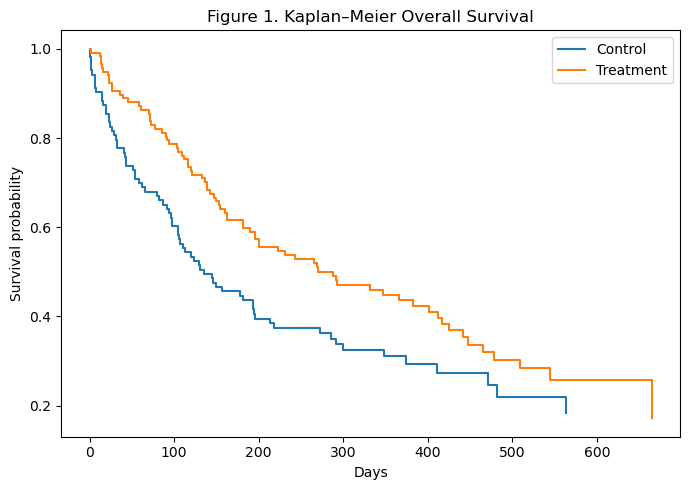

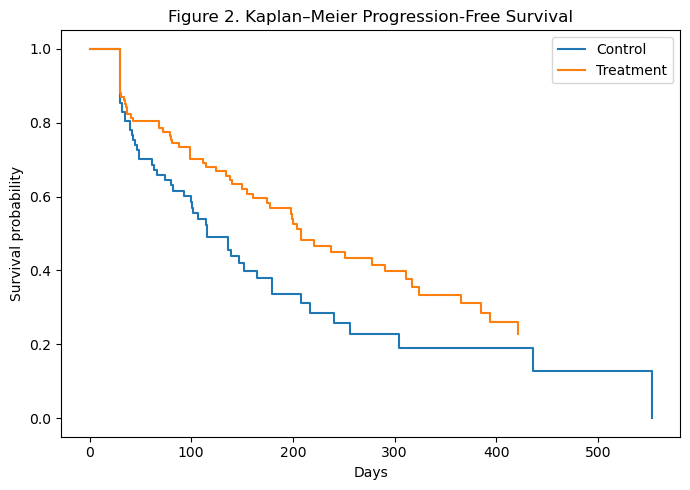

(         arm  median    n  events
 0    Control 135.000  103      74
 1  Treatment 288.000  117      76,
          arm  median    n  events
 0    Control 116.000  103      56
 1  Treatment 208.000  117      61)

In [54]:
# KM plots using a simple Kaplan-Meier implementation
def plot_km(df, title, outpath):
    plt.figure(figsize=(7,5))
    rows = []
    for arm in ["Control","Treatment"]:
        sub = df[df["TRT01A"] == arm].copy()
        km = km_curve(sub["AVAL"], 1 - sub["CNSR"])
        plt.step(km["time"], km["surv"], where="post", label=arm)
        rows.append({"arm": arm, "median": km_median(km), "n": len(sub), "events": int((1-sub['CNSR']).sum())})
    plt.xlabel("Days")
    plt.ylabel("Survival probability")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)

os_df = adtte[adtte["PARAMCD"]=="OS"].copy()
pfs_df = adtte[adtte["PARAMCD"]=="PFS"].copy()

os_summary = plot_km(os_df, "Figure 1. Kaplan–Meier Overall Survival", FIG_DIR / "figure_1_km_overall_survival.png")
pfs_summary = plot_km(pfs_df, "Figure 2. Kaplan–Meier Progression-Free Survival", FIG_DIR / "figure_2_km_progression_free_survival.png")

os_summary, pfs_summary

In [56]:
os_stats = approx_rate_hr(os_df)
pfs_stats = approx_rate_hr(pfs_df)

pd.DataFrame([
    {"endpoint":"OS", **os_stats},
    {"endpoint":"PFS", **pfs_stats},
])

,endpoint,hr,lcl,ucl,p_value
0,OS,0.661,0.480,0.911,0.011
1,PFS,0.601,0.418,0.864,0.006


In [58]:
# Subgroup incidence-rate HRs for OS
subgroup_rows = []
os_sub = os_df.copy()
if "AGE" not in os_sub.columns:
    os_sub = os_sub.merge(adsl[["USUBJID","AGE","SEX","TRGHIGHFL"]], on="USUBJID", how="left")
if "SEX" not in os_sub.columns:
    os_sub = os_sub.merge(adsl[["USUBJID","SEX"]], on="USUBJID", how="left")
if "TRGHIGHFL" not in os_sub.columns:
    os_sub = os_sub.merge(adsl[["USUBJID","TRGHIGHFL"]], on="USUBJID", how="left")
if "BIOMARKER_STATUS" not in os_sub.columns:
    os_sub = os_sub.merge(adsl[["USUBJID","BIOMARKER_STATUS"]], on="USUBJID", how="left")
if "ECOG" not in os_sub.columns and "ECOG_x" in os_sub.columns:
    os_sub["ECOG"] = os_sub["ECOG_x"]
elif "ECOG" not in os_sub.columns and "ECOG_y" in os_sub.columns:
    os_sub["ECOG"] = os_sub["ECOG_y"]

os_sub["AGEGR"] = np.where(os_sub["AGE"] < os_sub["AGE"].median(), "<Median age", "≥Median age")
groups = {
    "SEX": os_sub["SEX"].dropna().unique(),
    "AGEGR": os_sub["AGEGR"].dropna().unique(),
    "ECOG": sorted(pd.Series(os_sub["ECOG"]).dropna().unique()),
    "BIOMARKER_STATUS": os_sub["BIOMARKER_STATUS"].dropna().unique(),
    "TRGHIGHFL": os_sub["TRGHIGHFL"].dropna().unique(),
}
for subgroup, levels in groups.items():
    for lv in levels:
        d = os_sub[os_sub[subgroup] == lv].copy()
        if len(d) == 0 or d["TRT01A"].nunique() < 2:
            subgroup_rows.append({"subgroup": subgroup, "level": str(lv), "n": len(d), "events": int((1-d["CNSR"]).sum()), "hr": np.nan, "lcl": np.nan, "ucl": np.nan, "p_value": np.nan})
        else:
            s = approx_rate_hr(d)
            subgroup_rows.append({"subgroup": subgroup, "level": str(lv), "n": len(d), "events": int((1-d["CNSR"]).sum()), **s})
subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df.head()

,subgroup,level,n,events,hr,lcl,ucl,p_value
0,SEX,Male,125,87,0.631,0.414,0.960,0.032
1,SEX,Female,95,63,0.709,0.432,1.164,0.174
2,AGEGR,≥Median age,123,95,0.648,0.433,0.968,0.034
3,AGEGR,<Median age,97,55,0.700,0.412,1.189,0.187
4,ECOG,0,71,47,0.852,0.479,1.514,0.584


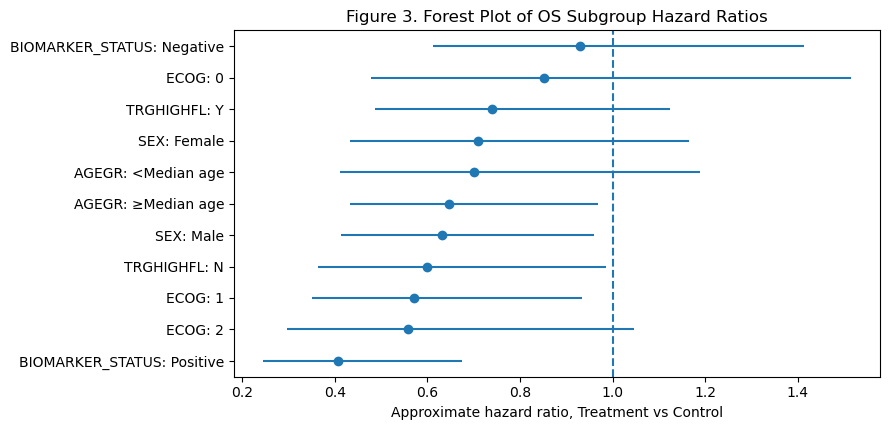

In [60]:
def forest_plot(df, title, outpath):
    plot_df = df.dropna(subset=["hr","lcl","ucl"]).copy()
    if plot_df.empty:
        plt.figure(figsize=(8,4))
        plt.text(0.5,0.5,"No estimable subgroup hazard ratios", ha="center", va="center")
        plt.axis("off")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        plt.show()
        return
    plot_df = plot_df.sort_values("hr").reset_index(drop=True)
    y = np.arange(len(plot_df))
    plt.figure(figsize=(9, max(4, 0.4*len(plot_df))))
    plt.errorbar(plot_df["hr"], y, xerr=[plot_df["hr"]-plot_df["lcl"], plot_df["ucl"]-plot_df["hr"]], fmt="o")
    plt.axvline(1.0, linestyle="--")
    plt.yticks(y, plot_df["subgroup"] + ": " + plot_df["level"])
    plt.xlabel("Approximate hazard ratio, Treatment vs Control")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

forest_plot(subgroup_df, "Figure 3. Forest Plot of OS Subgroup Hazard Ratios", FIG_DIR / "figure_3_forest_plot_os_subgroups.png")

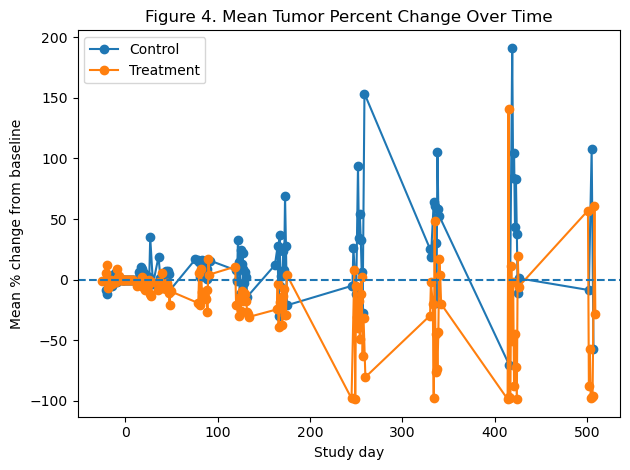

In [62]:
mean_tumor = adtu.groupby(["TRT01A","AVISITN"], as_index=False)["PCHG"].mean()
for arm in ["Control","Treatment"]:
    sub = mean_tumor[mean_tumor["TRT01A"] == arm]
    plt.plot(sub["AVISITN"], sub["PCHG"], marker="o", label=arm)
plt.axhline(0, linestyle="--")
plt.xlabel("Study day")
plt.ylabel("Mean % change from baseline")
plt.title("Figure 4. Mean Tumor Percent Change Over Time")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_4_mean_tumor_percent_change_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

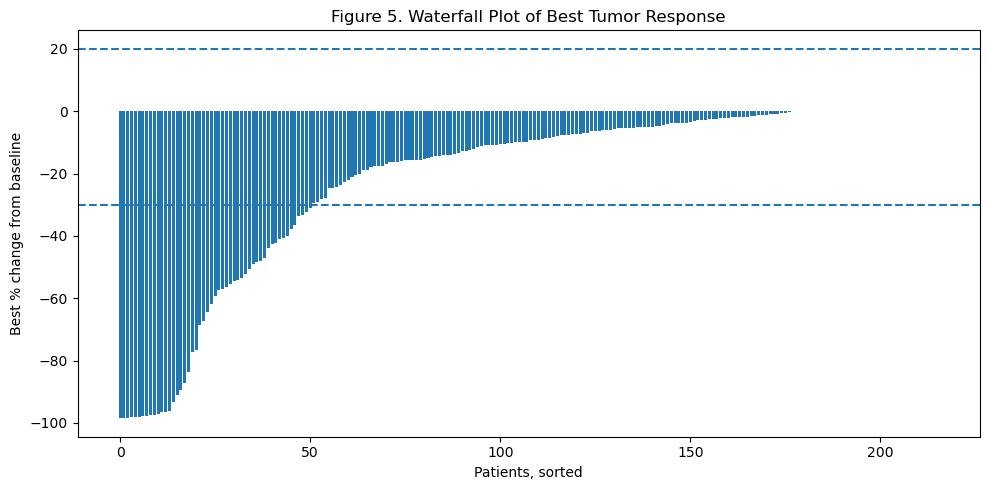

,USUBJID,PCHG,TRT01A
0,P0117,-98.506,Treatment
1,P0040,-98.430,Treatment
2,P0210,-98.277,Treatment
3,P0004,-98.101,Treatment
4,P0135,-98.095,Treatment


In [64]:
best_resp = adtu.groupby("USUBJID", as_index=False)["PCHG"].min().merge(adsl[["USUBJID","TRT01A"]], on="USUBJID", how="left")
best_resp = best_resp.sort_values("PCHG").reset_index(drop=True)
plt.figure(figsize=(10,5))
plt.bar(np.arange(len(best_resp)), best_resp["PCHG"])
plt.axhline(-30, linestyle="--")
plt.axhline(20, linestyle="--")
plt.xlabel("Patients, sorted")
plt.ylabel("Best % change from baseline")
plt.title("Figure 5. Waterfall Plot of Best Tumor Response")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_5_waterfall_plot_best_tumor_response.png", dpi=300, bbox_inches="tight")
plt.show()
best_resp.head()

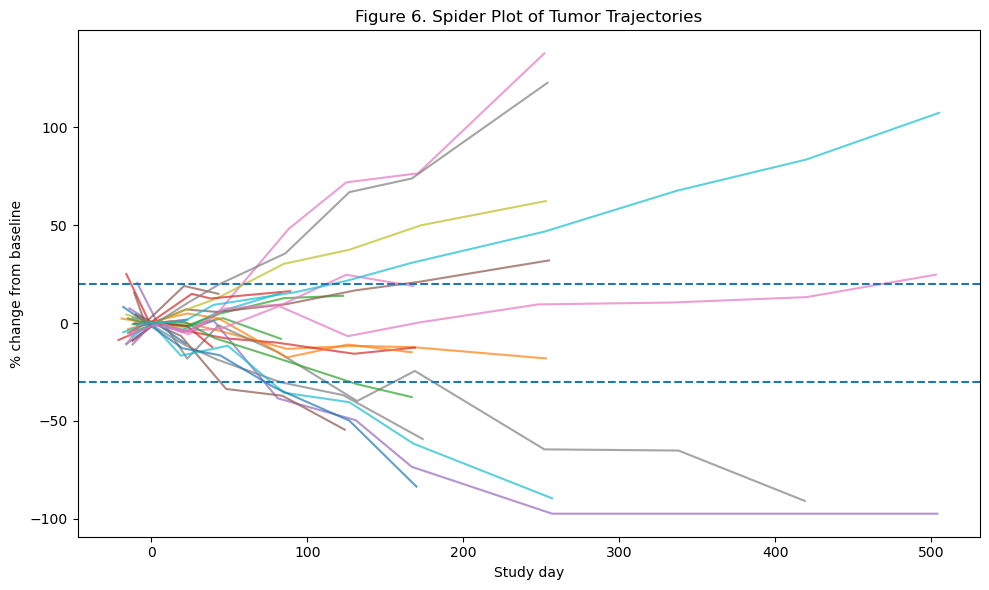

In [66]:
sample_ids = best_resp["USUBJID"].sample(30, random_state=42).tolist()
spider = adtu[adtu["USUBJID"].isin(sample_ids)]
plt.figure(figsize=(10,6))
for pid, d in spider.groupby("USUBJID"):
    plt.plot(d["AVISITN"], d["PCHG"], alpha=0.7)
plt.axhline(-30, linestyle="--")
plt.axhline(20, linestyle="--")
plt.xlabel("Study day")
plt.ylabel("% change from baseline")
plt.title("Figure 6. Spider Plot of Tumor Trajectories")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_6_spider_plot_tumor_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

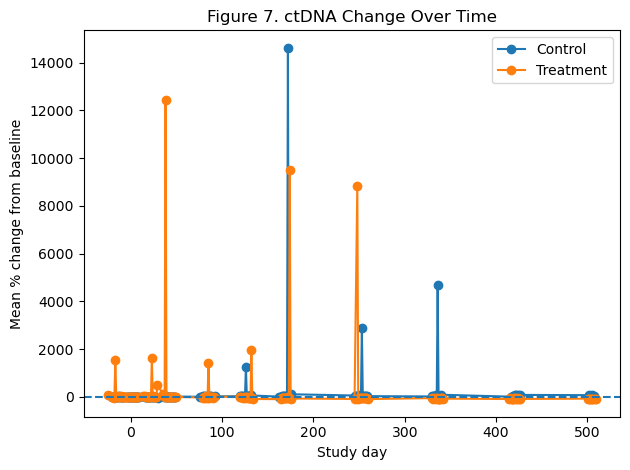

In [68]:
ctdna = adbm[adbm["PARAM"]=="ctDNA_fraction"].copy()
ctdna_mean = ctdna.groupby(["TRT01A","AVISITN"], as_index=False)["PCHG"].mean()
for arm in ["Control","Treatment"]:
    sub = ctdna_mean[ctdna_mean["TRT01A"]==arm]
    plt.plot(sub["AVISITN"], sub["PCHG"], marker="o", label=arm)
plt.axhline(0, linestyle="--")
plt.xlabel("Study day")
plt.ylabel("Mean % change from baseline")
plt.title("Figure 7. ctDNA Change Over Time")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_7_biomarker_change_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

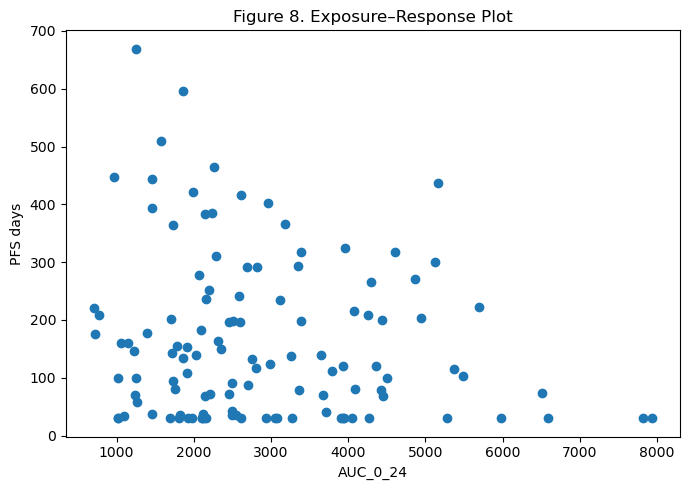

,AUC_0_24,PFDAYS
AUC_0_24,1.000,-0.160
PFDAYS,-0.160,1.000


In [70]:
er = adsl[adsl["TRT01A"]=="Treatment"].copy()
plt.figure(figsize=(7,5))
plt.scatter(er["AUC_0_24"], er["PFDAYS"])
plt.xlabel("AUC_0_24")
plt.ylabel("PFS days")
plt.title("Figure 8. Exposure–Response Plot")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_8_exposure_response_plot.png", dpi=300, bbox_inches="tight")
plt.show()

er[["AUC_0_24","PFDAYS"]].corr()

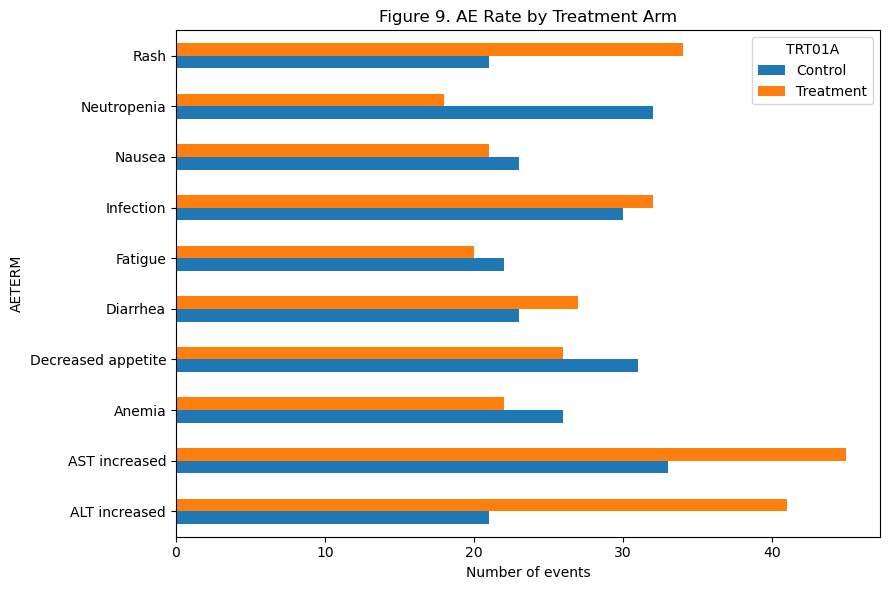

TRT01A,Control,Treatment
AETERM,,
ALT increased,21,41
AST increased,33,45
Anemia,26,22
Decreased appetite,31,26
Diarrhea,23,27
Fatigue,22,20
Infection,30,32
Nausea,23,21
Neutropenia,32,18


In [72]:
ae_rate = adae.groupby(["TRT01A","AETERM"], as_index=False).size()
pivot = ae_rate.pivot(index="AETERM", columns="TRT01A", values="size").fillna(0)
pivot.plot(kind="barh", figsize=(9,6))
plt.title("Figure 9. AE Rate by Treatment Arm")
plt.xlabel("Number of events")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_9_ae_rate_by_treatment_arm.png", dpi=300, bbox_inches="tight")
plt.show()
pivot

## 5. Tables/Figures

In [75]:
tbl1 = adsl.groupby("TRT01A").agg(
    N=("USUBJID","size"), AGE_MEAN=("AGE","mean"), FEMALE_N=("SEX", lambda s: int((s=="Female").sum())),
    ECOG0_N=("ECOG", lambda s: int((s==0).sum())), ECOG1_N=("ECOG", lambda s: int((s==1).sum())),
    ECOG2_N=("ECOG", lambda s: int((s==2).sum())), TUMORBL_MEAN=("TUMORBL","mean"),
    LDHBL_MEAN=("LDHBL","mean"), CRPBL_MEAN=("CRPBL","mean"), ALBBL_MEAN=("ALBBL","mean"),
    CTDNABL_MEAN=("CTDNABL","mean"), BIOMPOS_N=("BIOMARKER_STATUS", lambda s: int((s=="Positive").sum()))
).reset_index()
tbl1.to_csv(TAB_DIR / "table_1_baseline_characteristics.csv", index=False)
tbl1

,TRT01A,N,AGE_MEAN,FEMALE_N,ECOG0_N,ECOG1_N,ECOG2_N,TUMORBL_MEAN,LDHBL_MEAN,CRPBL_MEAN,ALBBL_MEAN,CTDNABL_MEAN,BIOMPOS_N
0,Control,103,62.748,43,32,52,19,101.361,254.022,12.985,3.882,0.141,44
1,Treatment,117,61.453,52,39,51,27,98.644,267.066,12.141,3.947,0.143,48


In [77]:
exp_summary = exposure_raw.groupby("patient_id").agg(
    cumulative_dose=("dose_mg","sum"),
    dose_reductions=("dose_reduction_flag", lambda s: int((pd.Series(s)=="Y").sum())),
    dose_interruptions=("dose_interruption_flag", lambda s: int((pd.Series(s)=="Y").sum()))
).reset_index().merge(adsl[["USUBJID","TRT01A","DOSEINTENSITY"]], left_on="patient_id", right_on="USUBJID", how="left")
tbl2 = exp_summary.groupby("TRT01A").agg(
    N=("USUBJID","size"), cumulative_dose_mean=("cumulative_dose","mean"),
    dose_intensity_mean=("DOSEINTENSITY","mean"), dose_reductions_total=("dose_reductions","sum"),
    dose_interruptions_total=("dose_interruptions","sum")
).reset_index()
tbl2.to_csv(TAB_DIR / "table_2_treatment_exposure.csv", index=False)
tbl2

,TRT01A,N,cumulative_dose_mean,dose_intensity_mean,dose_reductions_total,dose_interruptions_total
0,Control,92,0.000,NaN,0,0
1,Treatment,114,527.632,0.779,85,69


In [79]:
resp_counts = adsl.groupby(["TRT01A","BOR"]).size().unstack(fill_value=0)
tbl3 = resp_counts.copy()
tbl3["ORR"] = (tbl3.get("CR",0) + tbl3.get("PR",0)) / tbl3.sum(axis=1)
tbl3["CBR"] = (tbl3.get("CR",0) + tbl3.get("PR",0) + tbl3.get("SD",0)) / tbl3.sum(axis=1)
tbl3 = tbl3.reset_index()
tbl3.to_csv(TAB_DIR / "table_3_best_overall_response.csv", index=False)
tbl3

BOR,TRT01A,CR,PD,PR,SD,ORR,CBR
0,Control,3,39,24,37,0.262,0.620
1,Treatment,3,32,40,42,0.368,0.724


In [81]:
pts = adsl[["USUBJID","TRT01A"]].copy()
ae_flags2 = adae.groupby("USUBJID").agg(
    any_ae=("AESEQ","size"),
    gr3=("AETOXGR", lambda s: int((pd.Series(s) >= 3).any())),
    sae=("SERFL", lambda s: int((pd.Series(s) == "Y").any())),
    related=("RELFL", lambda s: int((pd.Series(s) == "Y").any())),
).reset_index()
ae_pat = pts.merge(ae_flags2, on="USUBJID", how="left")
ae_pat["any_ae"] = ae_pat["any_ae"].fillna(0).gt(0).astype(int)
for c in ["gr3","sae","related"]:
    ae_pat[c] = ae_pat[c].fillna(0).astype(int)
ae_pat = ae_pat.merge(adsl[["USUBJID","DISCFL"]], on="USUBJID", how="left")
ae_pat["disc"] = (ae_pat["DISCFL"] == "Y").astype(int)
rows = []
for c, label in [("any_ae","Any AE"),("gr3","Grade 3+ AE"),("sae","Serious AE"),("related","Related AE"),("disc","Discontinuation due to AE")]:
    tmp = ae_pat.groupby("TRT01A")[c].agg(["sum","count"]).reset_index()
    tmp["metric"] = label
    tmp["pct"] = 100 * tmp["sum"] / tmp["count"]
    rows.append(tmp)
tbl4 = pd.concat(rows, ignore_index=True)[["metric","TRT01A","sum","count","pct"]]
tbl4.to_csv(TAB_DIR / "table_4_adverse_event_summary.csv", index=False)
tbl4.head(10)

,metric,TRT01A,sum,count,pct
0,Any AE,Control,97,103,94.175
1,Any AE,Treatment,107,117,91.453
2,Grade 3+ AE,Control,52,103,50.485
3,Grade 3+ AE,Treatment,54,117,46.154
4,Serious AE,Control,18,103,17.476
5,Serious AE,Treatment,30,117,25.641
6,Related AE,Control,61,103,59.223
7,Related AE,Treatment,90,117,76.923
8,Discontinuation due to AE,Control,3,103,2.913
9,Discontinuation due to AE,Treatment,8,117,6.838


In [83]:
tbl5 = adlb.groupby(["TRT01A","PARAM"]).agg(mean_base=("BASE","mean"), mean_chg=("CHG","mean"), mean_pchg=("PCHG","mean")).reset_index()
tbl5.to_csv(TAB_DIR / "table_5_key_labs_over_time.csv", index=False)
tbl5.head(12)

,TRT01A,PARAM,mean_base,mean_chg,mean_pchg
0,Control,ALT,28.407,0.331,6.223
1,Control,AST,24.696,0.401,10.659
2,Control,Albumin,3.929,-0.054,-1.365
3,Control,CRP,12.014,0.373,40.500
4,Control,Creatinine,0.969,0.002,0.646
5,Control,Hemoglobin,12.377,-0.305,-2.371
6,Control,LDH,249.924,0.630,0.599
7,Control,Neutrophils,4.258,0.010,1.075
8,Control,Platelets,257.912,0.611,0.563
9,Treatment,ALT,30.799,0.343,8.185


In [85]:
tbl6 = adbm.groupby(["TRT01A","PARAM"]).agg(mean_base=("BASE","mean"), mean_chg=("CHG","mean"), mean_pchg=("PCHG","mean")).reset_index()
tbl6.to_csv(TAB_DIR / "table_6_biomarker_change_over_time.csv", index=False)
tbl6.head(12)

,TRT01A,PARAM,mean_base,mean_chg,mean_pchg
0,Control,IFNg,10.101,0.053,2.258
1,Control,IL6,12.167,0.558,24.879
2,Control,Ki67_score,41.975,0.196,0.899
3,Control,PDL1_score,26.465,0.680,7.607
4,Control,TNFa,9.753,0.730,13.122
5,Control,VEGF,266.039,3.433,1.527
6,Control,ctDNA_fraction,0.140,0.011,94.169
7,Treatment,IFNg,9.649,1.775,24.005
8,Treatment,IL6,12.917,0.691,19.402
9,Treatment,Ki67_score,44.298,-0.599,-1.137


In [87]:
tbl7 = pd.DataFrame([
    {"endpoint":"OS", "control_median": float(os_summary.loc[os_summary["arm"]=="Control","median"].iloc[0]), "treatment_median": float(os_summary.loc[os_summary["arm"]=="Treatment","median"].iloc[0]), **os_stats},
    {"endpoint":"PFS", "control_median": float(pfs_summary.loc[pfs_summary["arm"]=="Control","median"].iloc[0]), "treatment_median": float(pfs_summary.loc[pfs_summary["arm"]=="Treatment","median"].iloc[0]), **pfs_stats},
])
tbl7.to_csv(TAB_DIR / "table_7_survival_summary.csv", index=False)
subgroup_df.to_csv(TAB_DIR / "table_8_subgroup_hazard_ratios.csv", index=False)
tbl7

,endpoint,control_median,treatment_median,hr,lcl,ucl,p_value
0,OS,135.000,288.000,0.661,0.480,0.911,0.011
1,PFS,116.000,208.000,0.601,0.418,0.864,0.006


## 6. Decision

A flagship project should end with a decision-oriented interpretation, not just code and plots.

In [90]:
orr = adsl.groupby("TRT01A")["RESPFL"].apply(lambda s: (s=="Y").mean()).to_dict()
gr3 = adsl.groupby("TRT01A")["GR3AEFL"].apply(lambda s: (s=="Y").mean()).to_dict()

decision_lines = []
decision_lines.append("Flagship decision summary")
decision_lines.append("")
decision_lines.append(f"Observed ORR, Control: {100*orr.get('Control', np.nan):.1f}%")
decision_lines.append(f"Observed ORR, Treatment: {100*orr.get('Treatment', np.nan):.1f}%")
decision_lines.append(f"Grade 3+ AE rate, Control: {100*gr3.get('Control', np.nan):.1f}%")
decision_lines.append(f"Grade 3+ AE rate, Treatment: {100*gr3.get('Treatment', np.nan):.1f}%")
decision_lines.append(f"OS approximate HR, Treatment vs Control: {os_stats['hr']:.3f}")
decision_lines.append(f"PFS approximate HR, Treatment vs Control: {pfs_stats['hr']:.3f}")
decision_lines.append("")
if (orr.get("Treatment", 0) > orr.get("Control", 0)) and (gr3.get("Treatment", 1) < 0.50) and (os_stats["hr"] < 1) and (pfs_stats["hr"] < 1):
    decision_lines.append("Decision: the synthetic treatment arm shows a credible efficacy signal with manageable toxicity, supporting progression to a larger confirmatory or biomarker-enriched study.")
else:
    decision_lines.append("Decision: the synthetic treatment arm does not show a clearly favorable benefit-risk balance, suggesting dose, population, or biomarker refinement before further development.")

decision_text = "\n".join(decision_lines)
print(decision_text)

with open(TXT_DIR / "decision_summary.txt", "w") as f:
    f.write(decision_text)

Flagship decision summary

Observed ORR, Control: 26.2%
Observed ORR, Treatment: 36.8%
Grade 3+ AE rate, Control: 50.5%
Grade 3+ AE rate, Treatment: 46.2%
OS approximate HR, Treatment vs Control: 0.661
PFS approximate HR, Treatment vs Control: 0.601

Decision: the synthetic treatment arm shows a credible efficacy signal with manageable toxicity, supporting progression to a larger confirmatory or biomarker-enriched study.


In [92]:
manifest = pd.DataFrame({
    "folder": ["raw","adam","tables","figures","listings"],
    "n_files": [
        len(list(RAW_DIR.glob("*.csv"))),
        len(list(ADAM_DIR.glob("*.csv"))),
        len(list(TAB_DIR.glob("*"))),
        len(list(FIG_DIR.glob("*"))),
        len(list(TXT_DIR.glob("*"))),
    ]
})
manifest

,folder,n_files
0,raw,9
1,adam,6
2,tables,8
3,figures,9
4,listings,1
